# Diabetes Classification (Similar to Iris Example)
This notebook demonstrates a simple machine learning workflow using the **Pima Indians Diabetes dataset**.
The structure is similar to a typical Iris classification example: load data, explore, split data, train models, and evaluate performance.

## 1. Import Libraries

In [3]:
# Load libraries
import os, sys #os dung de doc duong dan file, tao xoa thu muc kiem tra file ton tai,sys lay tham so dong lenh vaf dung thoat chuong trinh
from IPython import display # dung cho viec hien hinh anh
import numpy as np
import matplotlib.pyplot as plt # ve do thi 
import pandas as pd # dung su ly du lieu dang bang doc , loc du lieu tu csv excel
import seaborn as sns # ve bieu do nang cao
import joblib # luu va load mo hinh machine learning

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder # chuyen du lieu thanh vecto ,text thanh so, du lieu thu tu
from sklearn.preprocessing import MinMaxScaler, StandardScaler # chuan hoa du lieu tu 0 ->1,Chuẩn hóa dữ liệu theo mean = 0 và std = 1
from sklearn.model_selection import train_test_split # chia va train/ test

import warnings

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [4]:
data_path = "data/pima-indians-diabetes.csv"

data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df_dataset = pd.read_csv(data_path, names=data_names)

## 3. Phân tích dữ liệu (Analyze Data)

In [5]:
# shape
print(f'+ Shape : {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape : (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nhận xét**:
+ Dữ liệu có 9 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome
+ Giá trị của từng tính chất lần lượt:số lần mang thai, mg/dL, mmHg, mm, µU/mL, kg/m², giá trị càng lờn càng bị
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột Outcome

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [7]:
has_null = df_dataset.isnull().sum().any() # tim null, roi xem co bao nhieu gia tri null,check co cai nao lon hon 0 ko
has_nan  = df_dataset.isna().sum().any()
n_duplicated = df_dataset.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')


Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: 0


#### (3) **Các tính chất thống kê trên dữ liệu số**


In [8]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Outcome) và dữ liệu danh mục (Category)**


In [9]:
df_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Kiểm tra dữ liệu

In [10]:
physiological_ranges = {
    "Pregnancies": (0, 20),
    "Glucose": (0, 200),
    "BloodPressure": (0, 140),
    "SkinThickness": (0, 100),
    "Insulin": (0, 900),
    "BMI": (0, 70),
    "DiabetesPedigreeFunction": (0, 2.5),
    "Age": (0, 120)
}

In [11]:
def detect_physiological_errors(df, physiological_ranges):
    errors = {}

    zero_invalid_cols = [
        "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
    ]

    for col, (min_val, max_val) in physiological_ranges.items():
        if col not in df.columns:
            continue
        
        invalid_mask = (df[col] < min_val) | (df[col] > max_val)

        # chỉ thêm điều kiện == 0 cho các cột cần
        if col in zero_invalid_cols:
            invalid_mask |= (df[col] == 0)

        invalid_values = df.loc[invalid_mask, col]

        if not invalid_values.empty:
            errors[col] = {
                "count": invalid_mask.sum(),
                "min_actual": df[col].min(),
                "max_actual": df[col].max(),
                "problem_values": invalid_values.tolist()
            }

    return errors

In [12]:
errors= detect_physiological_errors(df_dataset,physiological_ranges)
print ("====Dữ liệu lỗi được phát hiện====")
for col, info in errors.items():
    print(f"{col}:{info['count']} giá trị lỗi")
    print(f"- Range thực tế: {info['min_actual']}-{info['max_actual']}")
    print(f"- Giá trị có vấn đề  {info['problem_values']}")

====Dữ liệu lỗi được phát hiện====
Glucose:5 giá trị lỗi
- Range thực tế: 0-199
- Giá trị có vấn đề  [0, 0, 0, 0, 0]
BloodPressure:35 giá trị lỗi
- Range thực tế: 0-122
- Giá trị có vấn đề  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SkinThickness:227 giá trị lỗi
- Range thực tế: 0-99
- Giá trị có vấn đề  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Mối quan hệ giữa các tính chất 

**Phát hiện ngoại lệ và bất thường**

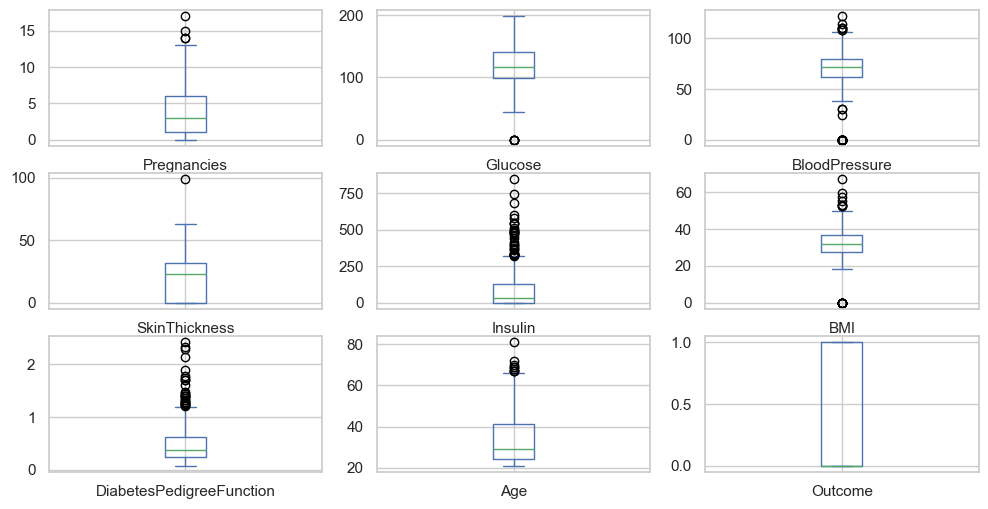

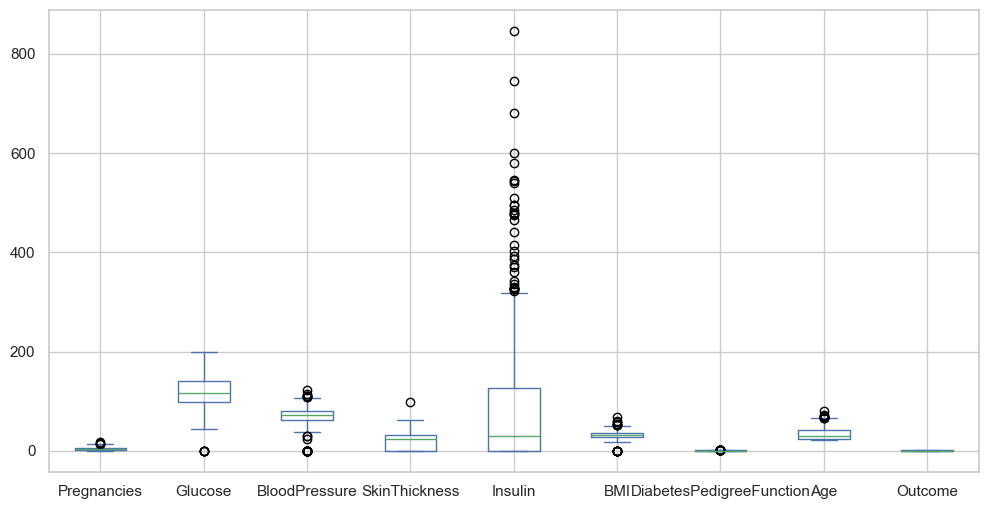

In [27]:
df_dataset.plot(kind="box", subplots=True, layout=(3, 3), sharex=False, sharey=False, figsize=(12,6));
df_dataset.plot(kind="box", figsize=(12,6));


**Phân bố của từng biến số**

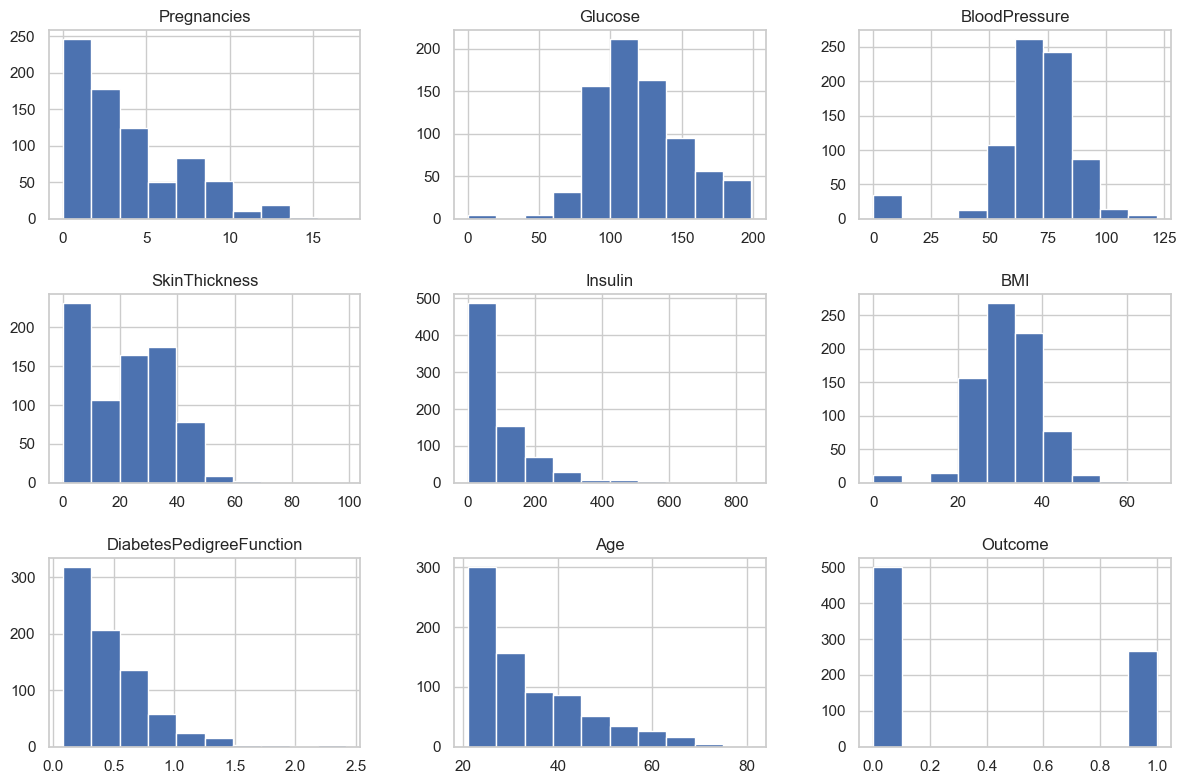

In [28]:
axes = df_dataset.hist(figsize=(12, 8), bins=10, sharex=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.show()

**Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh**

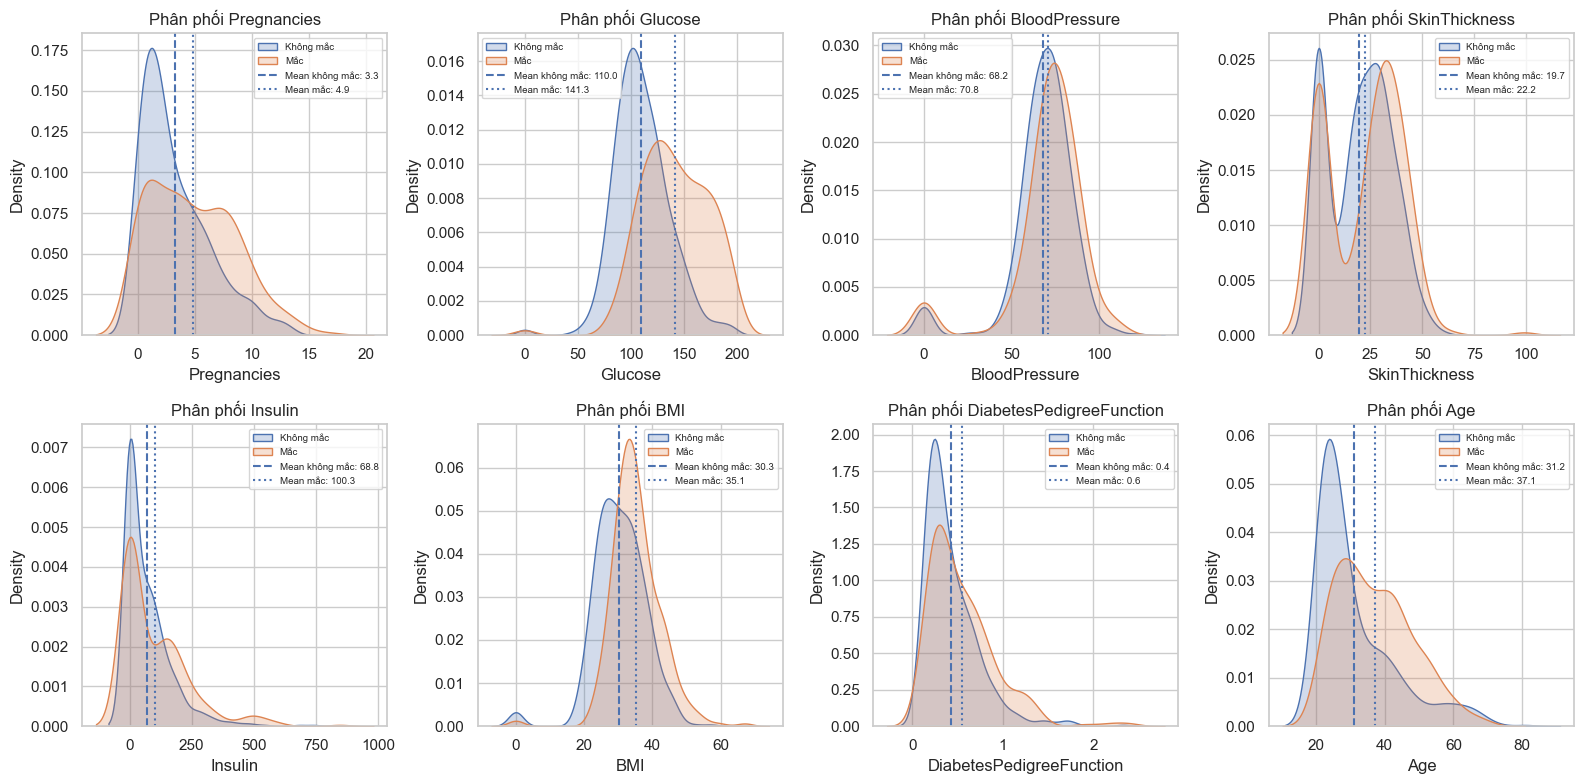

In [29]:

sns.set(style="whitegrid")

# Bỏ cột label ra danh sách riêng
features = df_dataset.columns.drop("Outcome")

# Tạo subplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    
    # Tách 2 nhóm
    data_0 = df_dataset[df_dataset["Outcome"] == 0][col]
    data_1 = df_dataset[df_dataset["Outcome"] == 1][col]
    
    # KDE plot
    sns.kdeplot(data_0, ax=ax, label="Không mắc", fill=True)
    sns.kdeplot(data_1, ax=ax, label="Mắc", fill=True)
    
    # Mean
    mean_0 = data_0.mean()
    mean_1 = data_1.mean()
    
    ax.axvline(mean_0, linestyle="--", label=f"Mean không mắc: {mean_0:.1f}")
    ax.axvline(mean_1, linestyle=":", label=f"Mean mắc: {mean_1:.1f}")
    
    # Title
    ax.set_title(f"Phân phối {col}")
    ax.legend(fontsize=7)

# Xóa ô thừa nếu có
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Tỷ lệ mắc bệnh đái tháo đường trong dataset

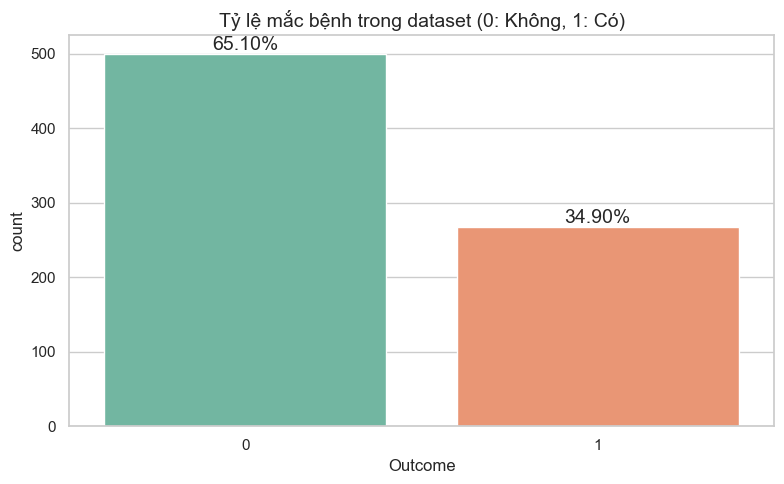

In [30]:


# Đếm số lượng từng lớp
counts = df_dataset["Outcome"].value_counts().sort_index()

# Tính phần trăm
percent = counts / counts.sum() * 100

# Vẽ biểu đồ
plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values, palette=["#66c2a5", "#fc8d62"])

# Thêm % lên đầu cột
for i, value in enumerate(counts.values):
    plt.text(i, value + 5, f"{percent[i]:.2f}%", ha='center', fontsize=14)

# Tiêu đề và nhãn
plt.title("Tỷ lệ mắc bệnh trong dataset (0: Không, 1: Có)", fontsize=14)
plt.xlabel("Outcome")
plt.ylabel("count")

plt.tight_layout()
plt.show()

**Phân bố bệnh theo độ tuổi**

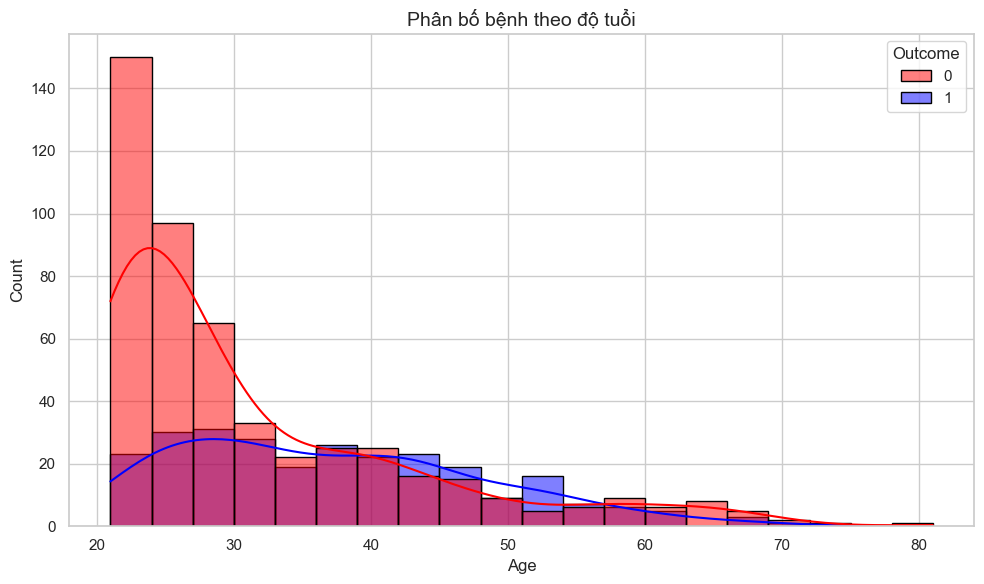

In [74]:

# Style cho đẹp
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_dataset,
    x="Age",
    hue="Outcome",       # 🔥 chia theo bệnh / không bệnh
    bins=20,
    kde=True,            # vẽ đường cong mượt
    palette=["red", "blue"],
    alpha=0.5,
    edgecolor="black"
)

plt.title("Phân bố bệnh theo độ tuổi", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**Các chỉ số sinh lý thay đổi theo tuổi**

BMI theo tuổi

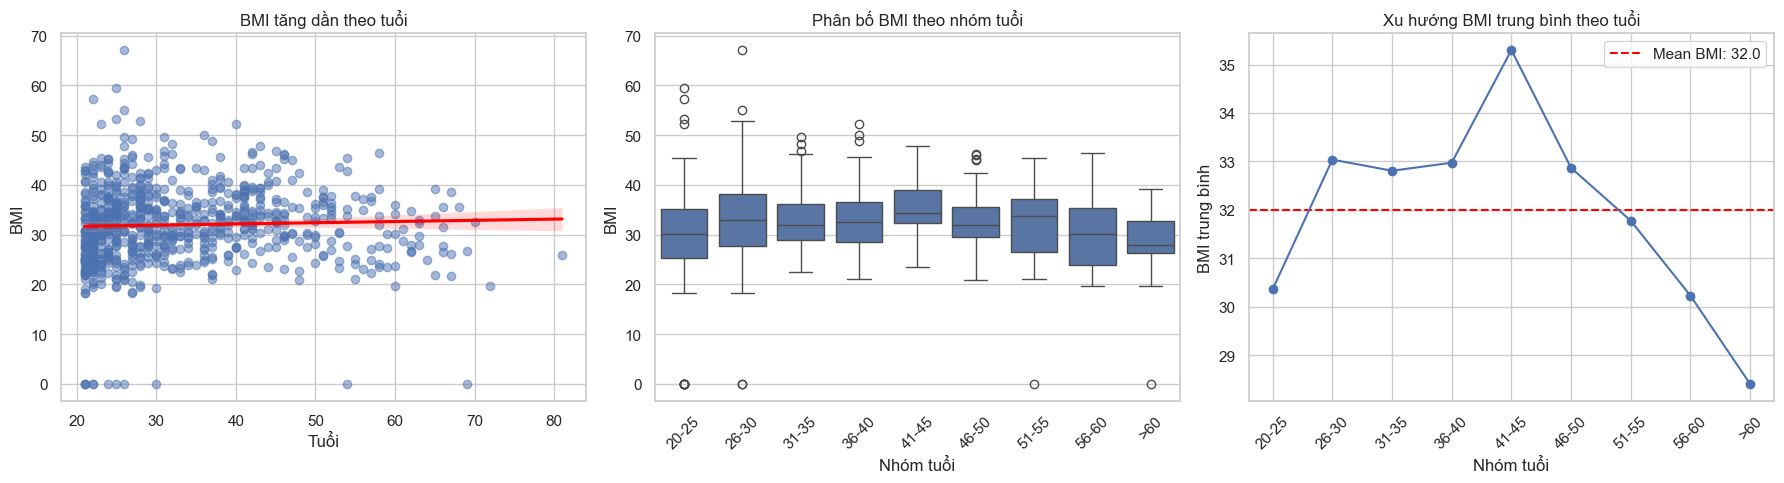

In [37]:


sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure 3 cột
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="BMI",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("BMI tăng dần theo tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("BMI")

# 🔹 2. Boxplot theo nhóm tuổi
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="BMI",
    ax=axes[1]
)
axes[1].set_title("Phân bố BMI theo nhóm tuổi")
axes[1].set_xlabel("Nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

# 🔹 3. Line chart (mean BMI)
mean_bmi = df_dataset.groupby("AgeGroup")["BMI"].mean()
overall_mean = df_dataset["BMI"].mean()

axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean BMI: {overall_mean:.1f}"
)
axes[2].plot(mean_bmi.index, mean_bmi.values, marker='o')
axes[2].set_title("Xu hướng BMI trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("BMI trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
plt.tight_layout()
plt.show()

Glucose theo tuổi

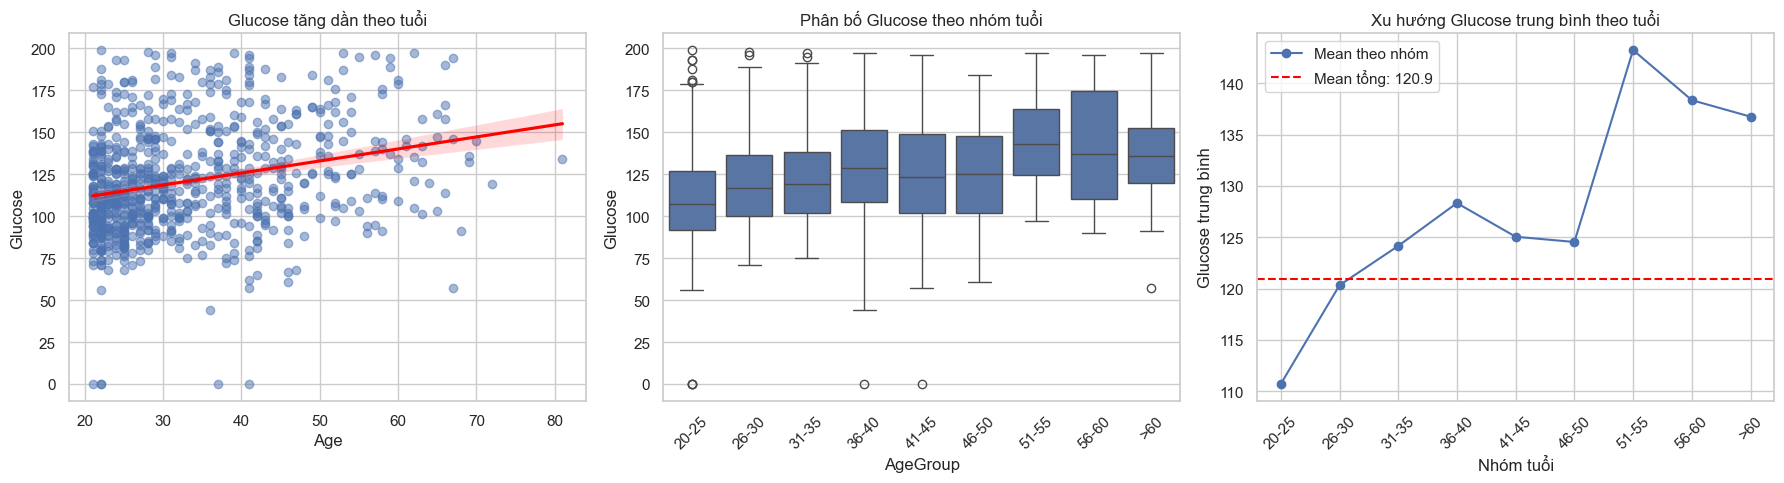

In [ ]:
sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="Glucose",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("Glucose tăng dần theo tuổi")

#  2. Boxplot
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="Glucose",
    ax=axes[1]
)
axes[1].set_title("Phân bố Glucose theo nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

#  3. Line chart
mean_glucose = df_dataset.groupby("AgeGroup")["Glucose"].mean()
overall_mean = df_dataset["Glucose"].mean()

axes[2].plot(mean_glucose.index, mean_glucose.values, marker='o', label="Mean theo nhóm")

#  đường trung bình tổng thể
axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean tổng: {overall_mean:.1f}"
)

axes[2].set_title("Xu hướng Glucose trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("Glucose trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

Huyết áp theo tuổi

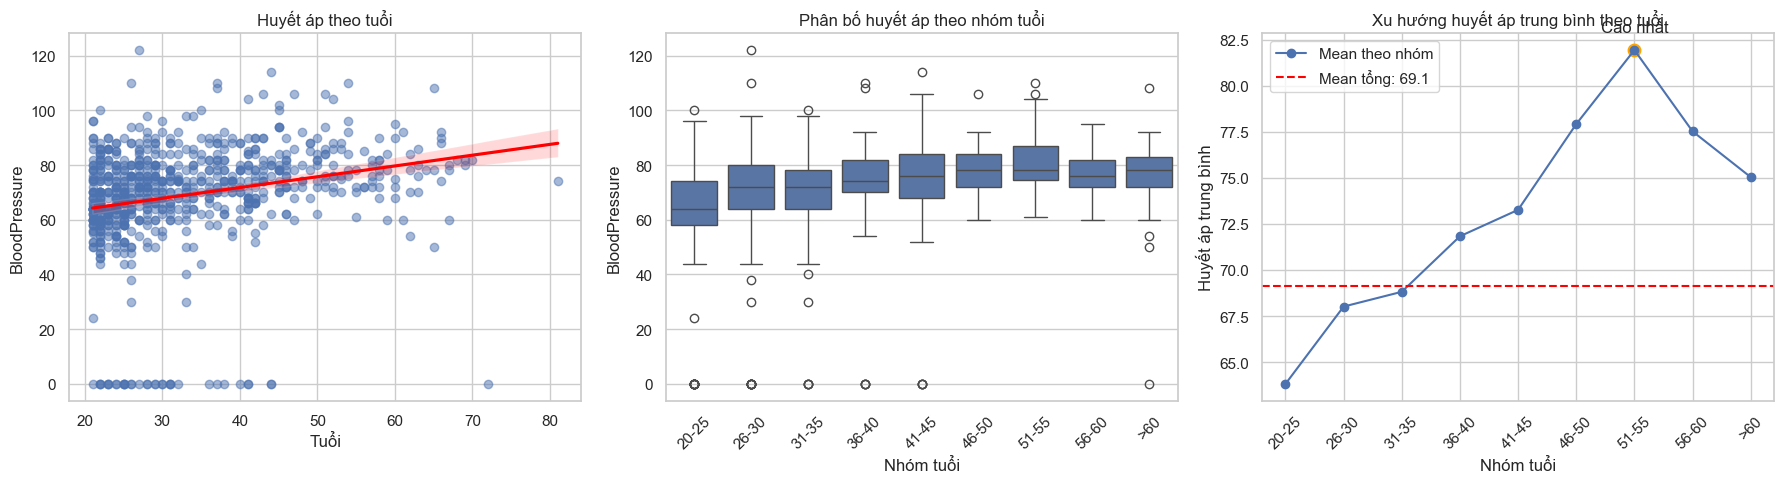

In [46]:


sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="BloodPressure",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("Huyết áp theo tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("BloodPressure")

# 🔹 2. Boxplot
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="BloodPressure",
    ax=axes[1]
)
axes[1].set_title("Phân bố huyết áp theo nhóm tuổi")
axes[1].set_xlabel("Nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

# 🔹 3. Line chart
mean_bp = df_dataset.groupby("AgeGroup")["BloodPressure"].mean()
overall_mean = df_dataset["BloodPressure"].mean()

axes[2].plot(mean_bp.index, mean_bp.values, marker='o', label="Mean theo nhóm")

# 👉 Đường trung bình tổng
axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean tổng: {overall_mean:.1f}"
)

# 👉 Highlight nhóm cao nhất
max_idx = mean_bp.idxmax()
max_val = mean_bp.max()
axes[2].scatter(max_idx, max_val, color='orange', s=80)
axes[2].text(max_idx, max_val+1, "Cao nhất", ha='center')

axes[2].set_title("Xu hướng huyết áp trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("Huyết áp trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

**Tỷ lệ phân bố theo nhóm tuổi**

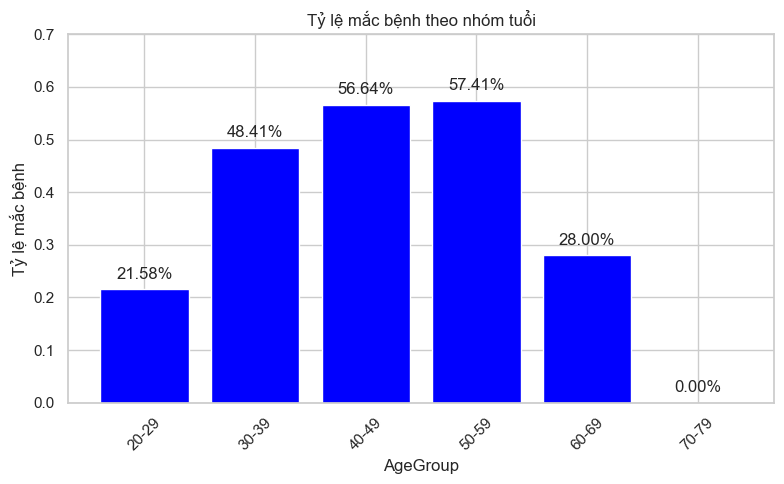

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#  1. Tạo nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ["20-29","30-39","40-49","50-59","60-69","70-79"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

#  2. Tính tỷ lệ mắc bệnh
rate = df_dataset.groupby("AgeGroup")["Outcome"].mean()

#  3. Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
plt.bar(rate.index, rate.values, color="blue")

plt.title("Tỷ lệ mắc bệnh theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tỷ lệ mắc bệnh")

#  4. Hiển thị % trên cột
for i, v in enumerate(rate):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center')

plt.xticks(rotation=45)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

Tỷ lệ mắc bệnh theo nhóm BMI

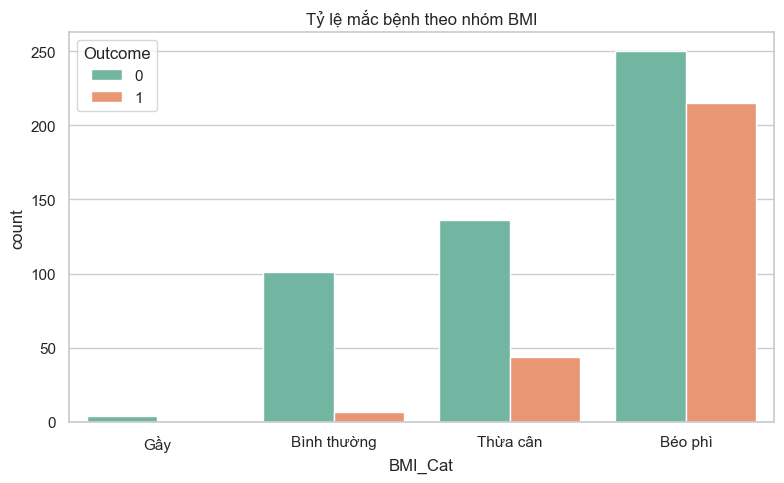

In [ ]:

sns.set(style="whitegrid")
#  1. Xử lý BMI (loại giá trị 0)
df_dataset["BMI"] = df_dataset["BMI"].replace(0, pd.NA)
df_dataset["BMI"] = pd.to_numeric(df_dataset["BMI"], errors="coerce")
#  2. Tạo nhóm BMI
bins = [0, 18.5, 25, 30, 100]
labels = ["Gầy", "Bình thường", "Thừa cân", "Béo phì"]

df_dataset["BMI_Cat"] = pd.cut(df_dataset["BMI"], bins=bins, labels=labels)

#  3. Vẽ countplot
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_dataset,
    x="BMI_Cat",
    hue="Outcome",
    palette="Set2"
)

plt.title("Tỷ lệ mắc bệnh theo nhóm BMI")
plt.xlabel("BMI_Cat")
plt.ylabel("count")

plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

Tỷ lệ mắc bệnh theo nhóm BMI

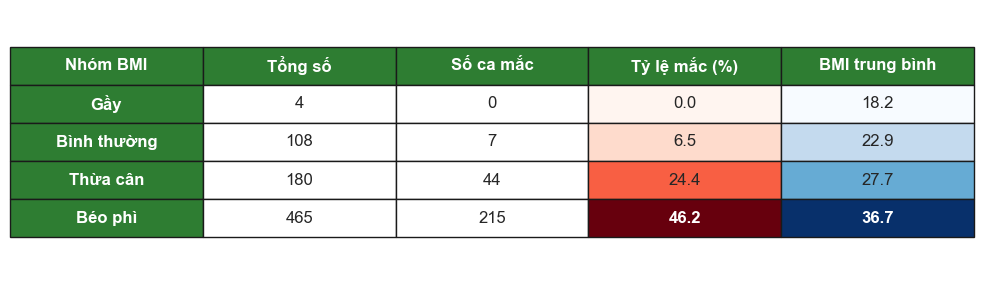

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ DataFrame
columns = result.columns.tolist()
data = result.values.tolist()

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

# Tạo bảng
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

#  Header màu xanh
for i in range(len(columns)):
    table[0, i].set_facecolor("#2e7d32")
    table[0, i].set_text_props(color="white", weight="bold")

#  Cột đầu (Nhóm BMI)
for i in range(1, len(data)+1):
    table[i, 0].set_facecolor("#2e7d32")
    table[i, 0].set_text_props(color="white", weight="bold")

#  Gradient cho "Tỷ lệ mắc (%)"
rate_col = columns.index("Tỷ lệ mắc (%)")
rate_values = result["Tỷ lệ mắc (%)"].values

# Chuẩn hóa về 0-1
rate_norm = (rate_values - rate_values.min()) / (rate_values.max() - rate_values.min())

for i, val in enumerate(rate_norm):
    color = plt.cm.Reds(val)
    table[i+1, rate_col].set_facecolor(color)
    if val > 0.7:
        table[i+1, rate_col].set_text_props(color="white", weight="bold")

#  Gradient cho "BMI trung bình"
bmi_col = columns.index("BMI trung bình")
bmi_values = result["BMI trung bình"].values

bmi_norm = (bmi_values - bmi_values.min()) / (bmi_values.max() - bmi_values.min())

for i, val in enumerate(bmi_norm):
    color = plt.cm.Blues(val)
    table[i+1, bmi_col].set_facecolor(color)
    if val > 0.7:
        table[i+1, bmi_col].set_text_props(color="white", weight="bold")

plt.tight_layout()
plt.show()

BMI và Glucose theo Outcome

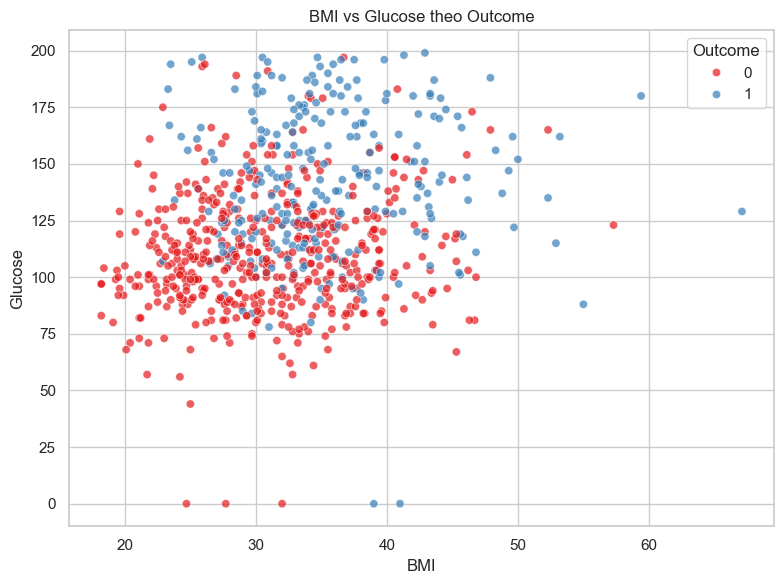

In [69]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Glucose",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Glucose theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Glucose")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

BMI và Age theo Outcome

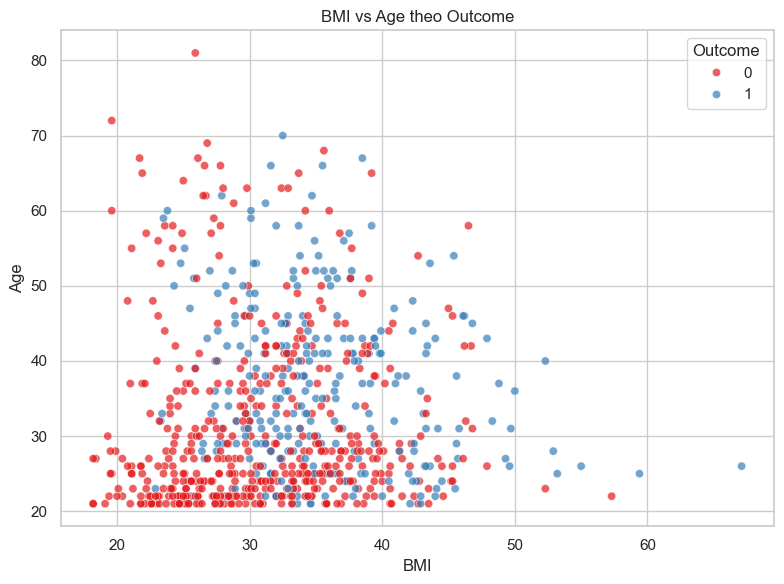

In [70]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Age",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Age theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Age")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

BMI và Insulin theo Outcome

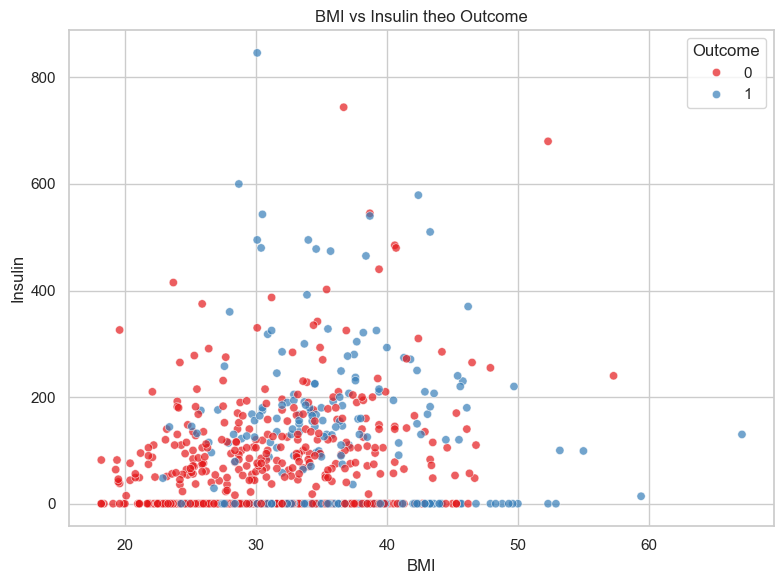

In [71]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Insulin",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Insulin theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Insulin")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Phân bố bệnh theo nồng độ Glucose

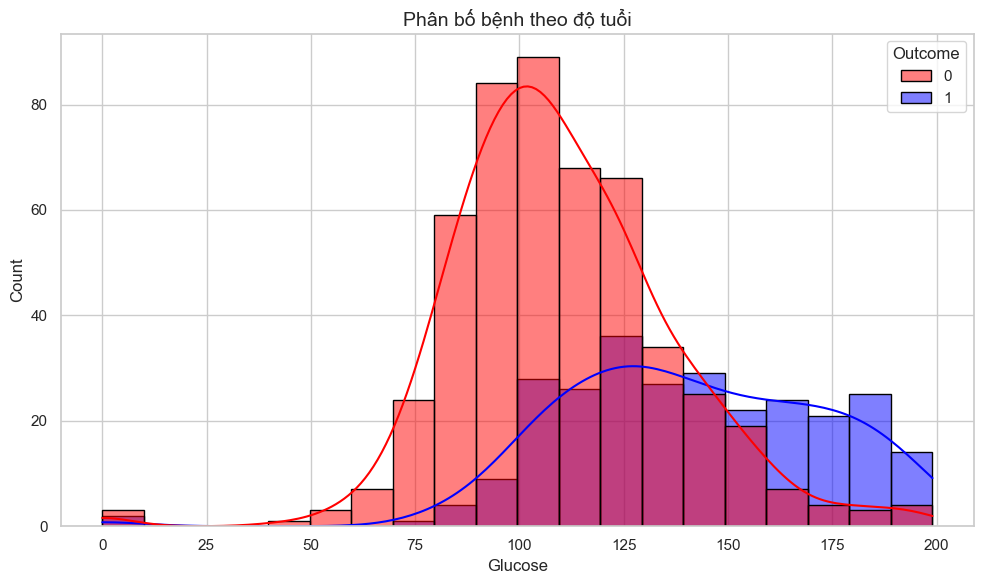

In [75]:

# Style cho đẹp
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_dataset,
    x="Glucose",
    hue="Outcome",       # 🔥 chia theo bệnh / không bệnh
    bins=20,
    kde=True,            # vẽ đường cong mượt
    palette=["red", "blue"],
    alpha=0.5,
    edgecolor="black"
)

plt.title("Phân bố bệnh theo độ tuổi", fontsize=14)
plt.xlabel("Glucose")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Glucose và insulin

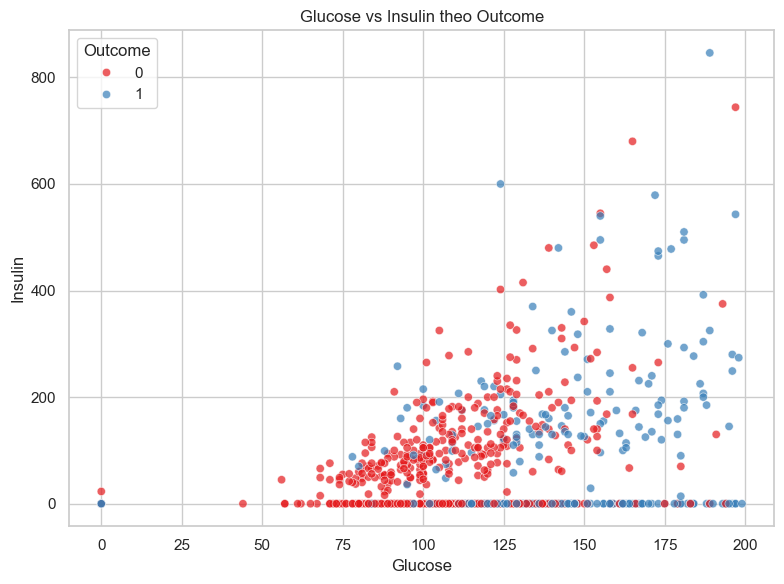

In [76]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="Glucose",
    y="Insulin",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("Glucose vs Insulin theo Outcome")
plt.xlabel("Glucose")
plt.ylabel("Insulin")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Phân bố Diabetes Pedigree Function

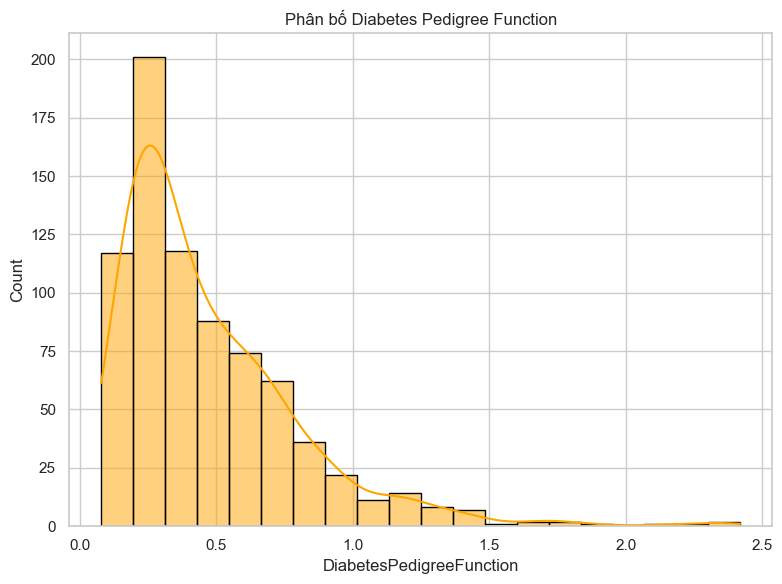

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.histplot(
    data=df_dataset,
    x="DiabetesPedigreeFunction",
    bins=20,
    kde=True,                # vẽ đường cong
    color="orange",
    edgecolor="black"
)

plt.title("Phân bố Diabetes Pedigree Function")
plt.xlabel("DiabetesPedigreeFunction")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Outcome theo yếu tố di chuyền

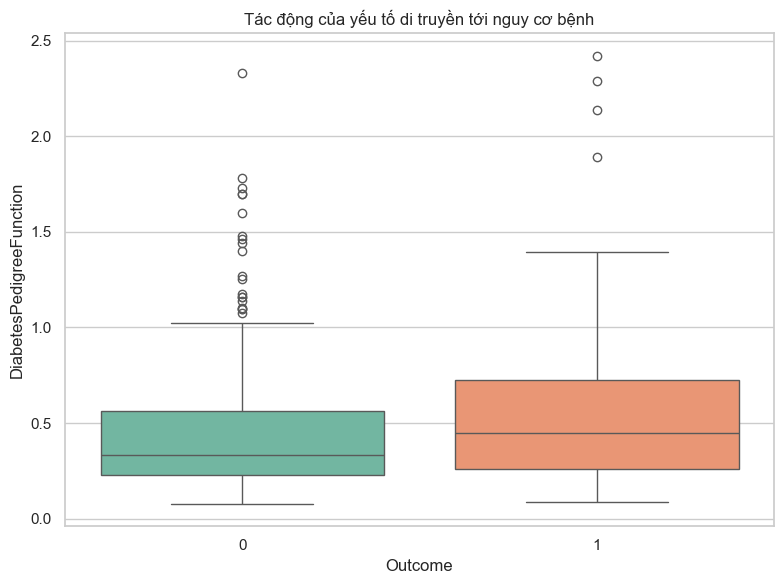

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_dataset,
    x="Outcome",
    y="DiabetesPedigreeFunction",
    palette=["#66c2a5", "#fc8d62"]  # xanh + cam giống hình
)

plt.title("Tác động của yếu tố di truyền tới nguy cơ bệnh")
plt.xlabel("Outcome")
plt.ylabel("DiabetesPedigreeFunction")

plt.tight_layout()
plt.show()

Di truyền kết hợp với Glucose

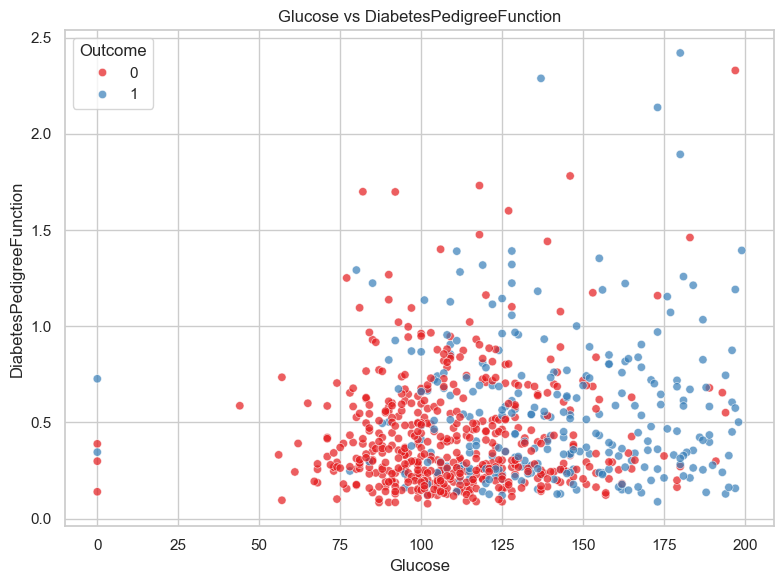

In [81]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="Glucose",
    y="DiabetesPedigreeFunction",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("Glucose vs DiabetesPedigreeFunction")
plt.xlabel("Glucose")
plt.ylabel("DiabetesPedigreeFunction")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Số lần có thai theo Outcome

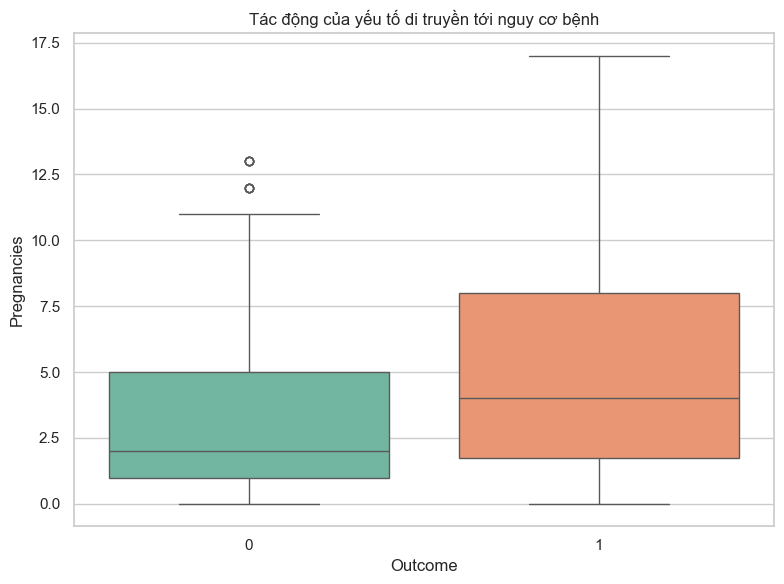

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_dataset,
    x="Outcome",
    y="Pregnancies",
    palette=["#66c2a5", "#fc8d62"]  # xanh + cam giống hình
)

plt.title("Tác động của yếu tố di truyền tới nguy cơ bệnh")
plt.xlabel("Outcome")
plt.ylabel("Pregnancies")

plt.tight_layout()
plt.show()

Nguy cơ đái tháo đường theo số lần có thai

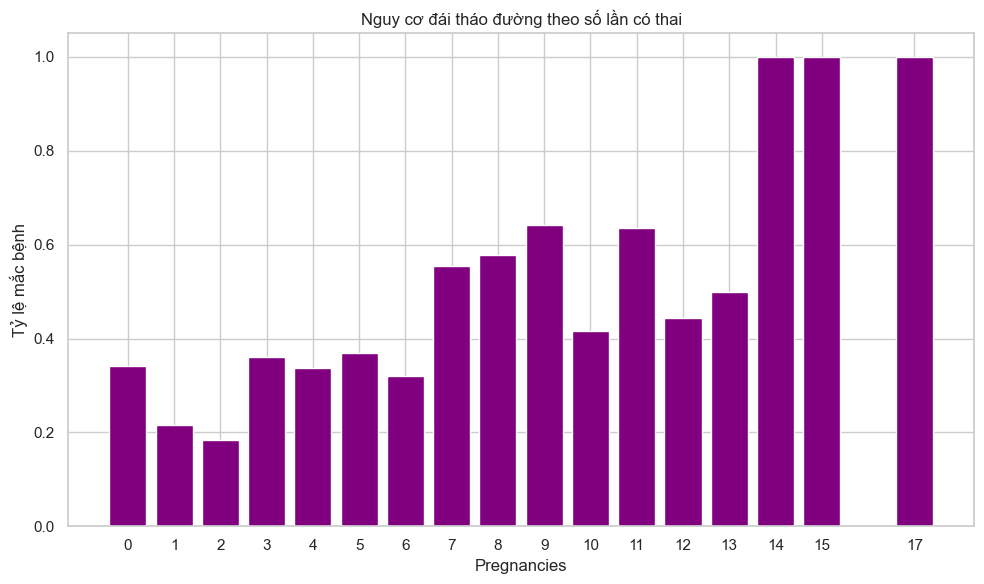

In [84]:
import matplotlib.pyplot as plt

# 🔹 Tính tỷ lệ mắc bệnh theo số lần mang thai
preg_rate = df_dataset.groupby("Pregnancies")["Outcome"].mean()

plt.figure(figsize=(10,6))

plt.bar(
    preg_rate.index,
    preg_rate.values,
    color="purple"
)

plt.title("Nguy cơ đái tháo đường theo số lần có thai")
plt.xlabel("Pregnancies")
plt.ylabel("Tỷ lệ mắc bệnh")

plt.xticks(preg_rate.index)  # hiện đầy đủ trục x

plt.tight_layout()
plt.show()

In [32]:
!jupyter nbconvert --to html pima_indian_diabetes.ipynb

[NbConvertApp] Converting notebook pima_indian_diabetes.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 950781 bytes to pima_indian_diabetes.html
